In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_parquet("../../data/processed/delivery_clean.parquet")
print(f"Loaded: {df.shape}")

city_dur = df.groupby('city')['delivery_duration_min'].agg(['median','mean','std','count'])
print("\nDelivery duration by city (minutes):")
print(city_dur.round(1).to_string())

Loaded: (4512573, 15)

Delivery duration by city (minutes):
           median   mean    std    count
city                                    
Chongqing   151.0  286.7  622.6   930297
Hangzhou    115.0  164.7  282.1  1860866
Jilin       175.0  203.5  142.7    31405
Shanghai     72.0  110.3  182.1  1483689
Yantai      208.0  267.6  290.4   206316


In [ ]:
df['real_date'] = df['ds'].map({d: pd.Timestamp(year=2022, month=d//100, day=d%100) for d in df['ds'].unique()})
df['day_of_week'] = df['real_date'].dt.dayofweek

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2-lat1, lon2-lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine(df['accept_gps_lat'], df['accept_gps_lng'],
                               df['delivery_gps_lat'], df['delivery_gps_lng'])

df['implied_speed_kmh'] = df['distance_km'] / (df['delivery_duration_min'].clip(lower=1)/60)

df['accept_hour'] = df['accept_time'].dt.hour
df['delivery_hour'] = df['delivery_time'].dt.hour

df['is_instant_delivery'] = (df['delivery_duration_min'] == 0).astype(int)
df['is_ghost_dispatch'] = df['accept_gps_lng'].isnull().astype(int)

print("EDA features built.")
print(f"distance_km nulls (from ghost dispatch): {df['distance_km'].isnull().sum():,}")
for c in ['distance_km','implied_speed_kmh','accept_hour','delivery_hour']:
    print(f"\n{c}:")
    print(df[c].describe(percentiles=[.5,.95,.99]).to_string())

EDA features built.
distance_km nulls (from ghost dispatch): 3,375

distance_km:
count    4.509198e+06
mean     2.831113e+00
std      1.152485e+01
min      0.000000e+00
50%      1.939130e+00
95%      7.563706e+00
99%      1.662804e+01
max      3.771600e+03

implied_speed_kmh:
count    4.509198e+06
mean     3.373522e+00
std      8.597961e+01
min      0.000000e+00
50%      1.159371e+00
95%      6.054686e+00
99%      3.288134e+01
max      9.665416e+04

accept_hour:
count    4.512573e+06
mean     1.156407e+01
std      3.473838e+00
min      0.000000e+00
50%      1.100000e+01
95%      1.700000e+01
99%      1.900000e+01
max      2.300000e+01

delivery_hour:
count    4.512573e+06
mean     1.396939e+01
std      3.453900e+00
min      0.000000e+00
50%      1.400000e+01
95%      2.000000e+01
99%      2.100000e+01
max      2.300000e+01


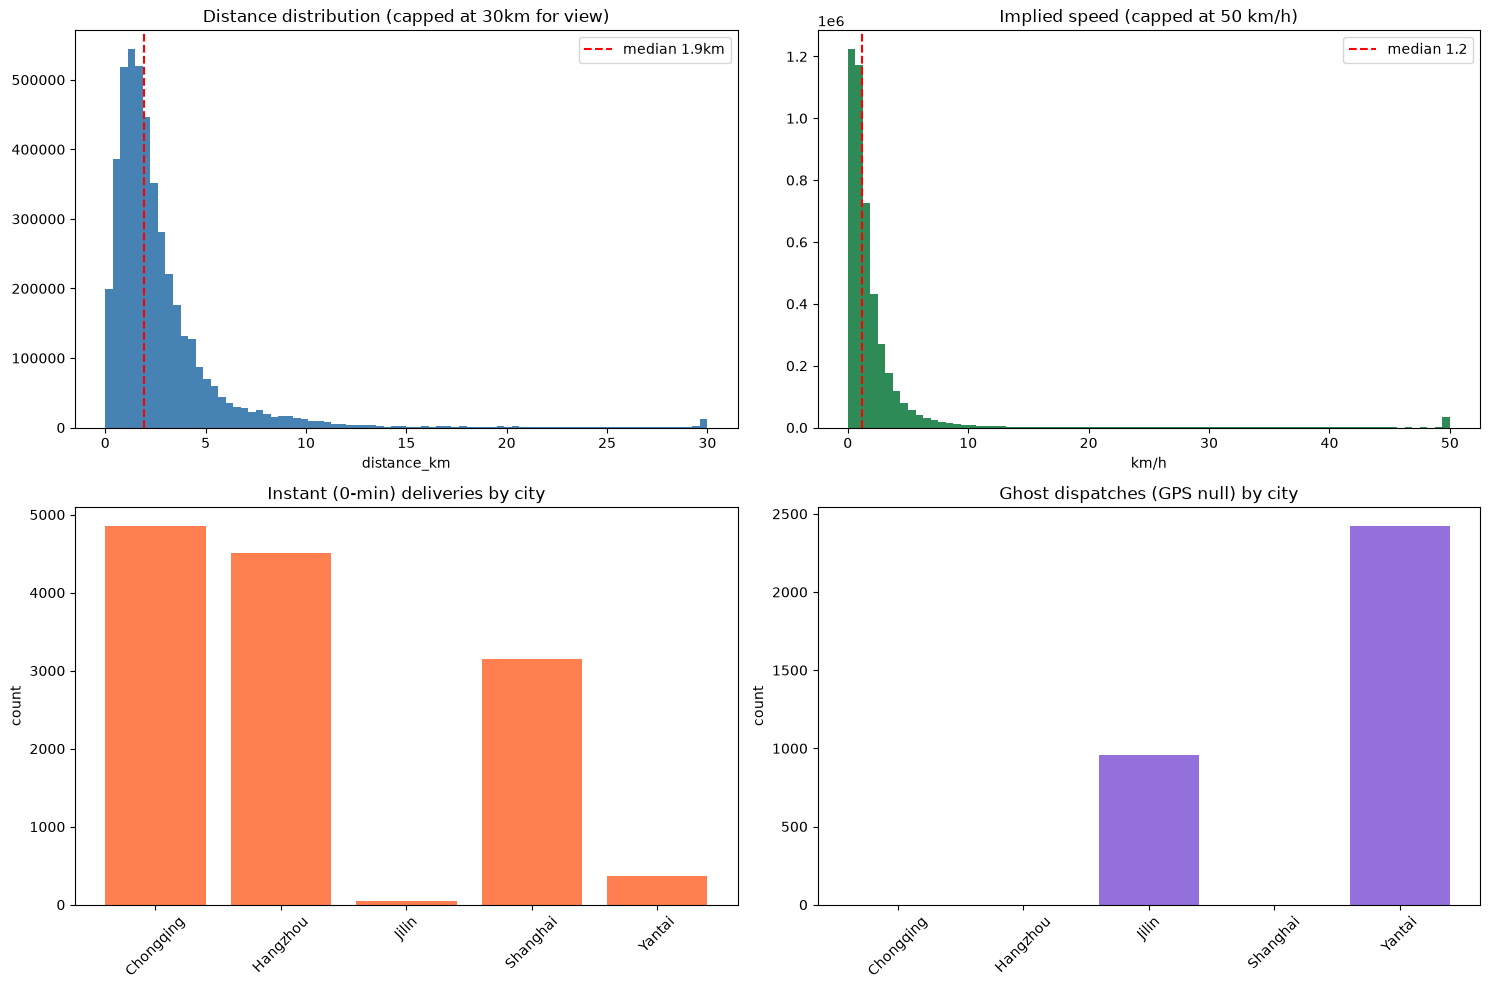

Instant deliveries by city:
            sum    mean
city                   
Chongqing  4850  0.0052
Hangzhou   4513  0.0024
Jilin        50  0.0016
Shanghai   3148  0.0021
Yantai      369  0.0018

Ghost dispatches by city:
            sum    mean
city                   
Chongqing     0  0.0000
Hangzhou      0  0.0000
Jilin       955  0.0304
Shanghai      0  0.0000
Yantai     2420  0.0117


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0,0].hist(df['distance_km'].clip(upper=30), bins=80, color='steelblue')
axes[0,0].axvline(df['distance_km'].median(), color='red', linestyle='--', label=f"median {df['distance_km'].median():.1f}km")
axes[0,0].set_title('Distance distribution (capped at 30km for view)')
axes[0,0].set_xlabel('distance_km'); axes[0,0].legend()

axes[0,1].hist(df['implied_speed_kmh'].clip(upper=50), bins=80, color='seagreen')
axes[0,1].axvline(df['implied_speed_kmh'].median(), color='red', linestyle='--', label=f"median {df['implied_speed_kmh'].median():.1f}")
axes[0,1].set_title('Implied speed (capped at 50 km/h)')
axes[0,1].set_xlabel('km/h'); axes[0,1].legend()

inst = df.groupby('city')['is_instant_delivery'].agg(['sum','mean'])
axes[1,0].bar(inst.index, inst['sum'], color='coral')
axes[1,0].set_title('Instant (0-min) deliveries by city')
axes[1,0].set_ylabel('count'); axes[1,0].tick_params(axis='x', rotation=45)

ghost = df.groupby('city')['is_ghost_dispatch'].agg(['sum','mean'])
axes[1,1].bar(ghost.index, ghost['sum'], color='mediumpurple')
axes[1,1].set_title('Ghost dispatches (GPS null) by city')
axes[1,1].set_ylabel('count'); axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()

print("Instant deliveries by city:")
print(df.groupby('city')['is_instant_delivery'].agg(['sum','mean']).round(4).to_string())
print("\nGhost dispatches by city:")
print(df.groupby('city')['is_ghost_dispatch'].agg(['sum','mean']).round(4).to_string())

In [ ]:
valid = df['distance_km'].notna()
sub = df[valid].copy()

corr = sub['distance_km'].corr(sub['delivery_duration_min'])
print(f"Correlation distance_km vs duration: {corr:.3f}")

sub['dist_bucket'] = pd.cut(sub['distance_km'], bins=[0,1,2,5,10,20,10000],
                             labels=['<1km','1-2km','2-5km','5-10km','10-20km','20km+'])
dist_dur = sub.groupby('dist_bucket')['delivery_duration_min'].agg(['median','count'])
print("\nMedian duration by distance bucket (should rise if coords are real):")
print(dist_dur.round(1).to_string())

print("\nDelivery GPS spread per city (std of lng/lat — should be small, city-sized):")
print(df.groupby('city')[['delivery_gps_lng','delivery_gps_lat']].std().round(3).to_string())

Correlation distance_km vs duration: 0.047

Median duration by distance bucket (should rise if coords are real):
             median    count
dist_bucket                 
<1km           76.0   928291
1-2km          88.0  1402322
2-5km         118.0  1682023
5-10km        192.0   383836
10-20km       265.0    79512
20km+         261.0    33200

Delivery GPS spread per city (std of lng/lat — should be small, city-sized):
           delivery_gps_lng  delivery_gps_lat
city                                         
Chongqing             0.362             0.257
Hangzhou              0.201             0.149
Jilin                 0.025             0.033
Shanghai              0.170             0.113
Yantai                0.358             0.204


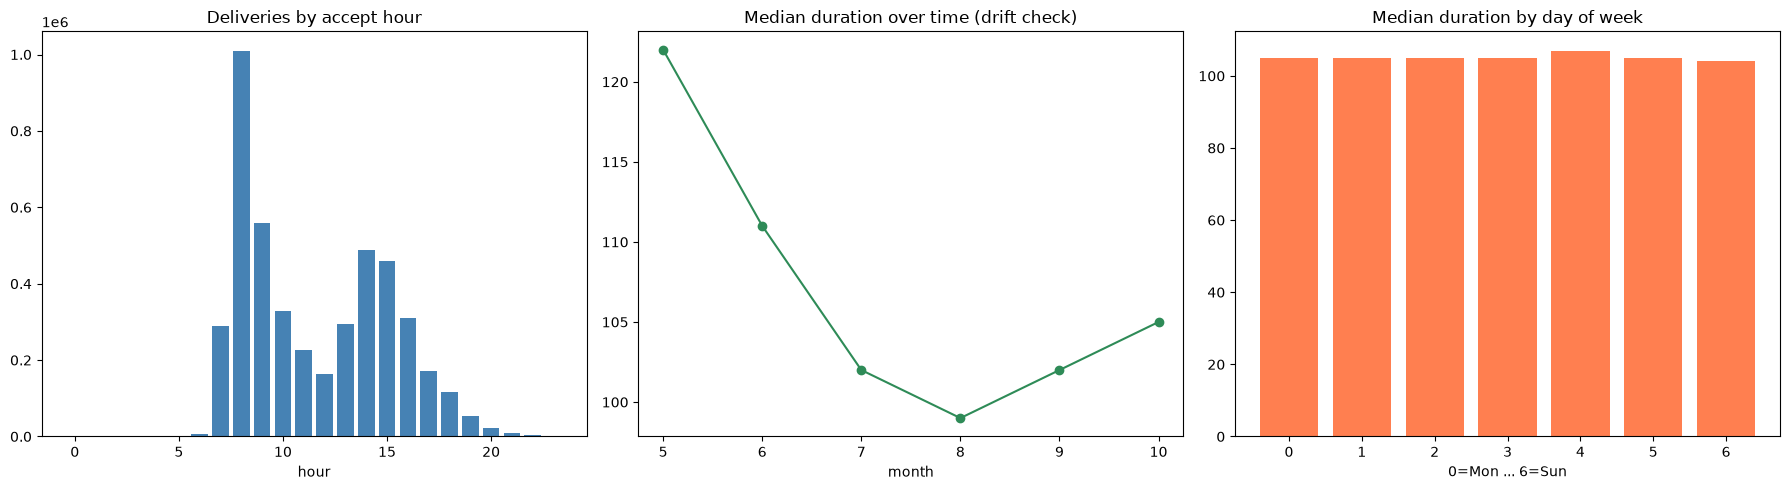

Accept hour — bottom 5 (odd hours):
accept_hour
0       4
1       1
2       7
3       1
4      36
5     630
6    7631


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

hr = df['accept_hour'].value_counts().sort_index()
axes[0].bar(hr.index, hr.values, color='steelblue')
axes[0].set_title('Deliveries by accept hour'); axes[0].set_xlabel('hour')

df['month'] = df['real_date'].dt.month
mon = df.groupby('month')['delivery_duration_min'].median()
axes[1].plot(mon.index, mon.values, marker='o', color='seagreen')
axes[1].set_title('Median duration over time (drift check)'); axes[1].set_xlabel('month')

dow = df.groupby('day_of_week')['delivery_duration_min'].median()
axes[2].bar(dow.index, dow.values, color='coral')
axes[2].set_title('Median duration by day of week'); axes[2].set_xlabel('0=Mon ... 6=Sun')

plt.tight_layout(); plt.show()

print("Accept hour — bottom 5 (odd hours):")
print(df['accept_hour'].value_counts().sort_index().head(7).to_string())

In [ ]:
print("Implied speed anomalies:")
for t in [40, 60, 100, 1000]:
    n = (df['implied_speed_kmh'] > t).sum()
    print(f"  speed > {t} km/h: {n:,} ({n/len(df)*100:.4f}%)")

feat_cols = ['delivery_duration_min','distance_km','implied_speed_kmh','accept_hour']
corr_matrix = df[feat_cols].corr()
print("\nFeature correlation matrix (for IF inputs):")
print(corr_matrix.round(3).to_string())

extreme_dur = df['delivery_duration_min'] > df['delivery_duration_min'].quantile(0.99)
extreme_dist = df['distance_km'] > df['distance_km'].quantile(0.99)
extreme_speed = df['implied_speed_kmh'] > df['implied_speed_kmh'].quantile(0.99)
multi = (extreme_dur.astype(int) + extreme_dist.astype(int) + extreme_speed.astype(int))
print(f"\nRows extreme on 2+ dimensions: {(multi>=2).sum():,}")
print(f"Rows extreme on all 3: {(multi==3).sum():,}")

Implied speed anomalies:
  speed > 40 km/h: 39,926 (0.8848%)
  speed > 60 km/h: 30,092 (0.6668%)
  speed > 100 km/h: 19,448 (0.4310%)
  speed > 1000 km/h: 385 (0.0085%)

Feature correlation matrix (for IF inputs):
                       delivery_duration_min  distance_km  implied_speed_kmh  accept_hour
delivery_duration_min                  1.000        0.047             -0.014       -0.122
distance_km                            0.047        1.000              0.303       -0.036
implied_speed_kmh                     -0.014        0.303              1.000        0.022
accept_hour                           -0.122       -0.036              0.022        1.000

Rows extreme on 2+ dimensions: 6,483
Rows extreme on all 3: 9
